# TPCQ-Net — Baseline Training
**Standard parameter-shift gradient — unstructured RY+CX global circuit**

Backward cost: `2 × n_gate_params` circuits per sample.  
Results saved to `results/baseline/` for comparison in notebook 03.

In [1]:
import os, sys, math, time, json
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from tqdm.auto import tqdm

sys.path.insert(0, '.')
from qc_circuits import build_local_circuit, build_global_circuit
from qc_runner import setup_baseline
from qc_model import build_baseline_model
from qc_train import (train_model, evaluate, make_loaders,
                       compute_circuit_counts, print_circuit_counts,
                       _stratified_indices)
from qc_logs import compute_analysis, print_analysis

torch.manual_seed(42)
np.random.seed(42)
os.makedirs('results/baseline', exist_ok=True)
print('Imports OK')


C:\Users\Mominul\anaconda3\envs\qml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


## Configuration

Set `DATASET_MODE = 'subset'` for a fast stratified subset, or `'full'` for all of MNIST.

In [2]:
class CFG:
    # ── quantum architecture ───────────────────────────────────────────
    N_QUBITS          = 3
    N_Q_LAYERS        = 3
    N_Q_LAYERS_GLOBAL = 6
    N_MEASURE_BASES   = 3        # Z, X, Y → 9 outputs per quantum branch

    # ── feature map ───────────────────────────────────────────────────
    Q_RES    = 5
    Q_STRIDE = 3

    # ── Aer backend ───────────────────────────────────────────────────
    AER_METHOD = 'statevector'
    AER_SHOTS  = None            # None = exact statevector

    # ── dataset ───────────────────────────────────────────────────────
    #   'subset' → stratified subset (all 10 classes always represented)
    #   'full'   → entire MNIST train (60k) / test (10k)
    DATASET_MODE  = 'subset'
    TRAIN_SAMPLES = 2500         # used when DATASET_MODE='subset'
    VAL_SAMPLES   = 200          # used when DATASET_MODE='subset'

    # ── training ──────────────────────────────────────────────────────
    BATCH_SIZE = 16
    EPOCHS     = 3
    LR         = 1e-3

    # ── output paths ──────────────────────────────────────────────────
    CSV_PATH   = 'results/baseline/training_log.csv'
    MODEL_PATH = 'results/baseline/model_best.pth'

    # ── derived (do not edit) ─────────────────────────────────────────
    @classmethod
    def n_inputs(cls):
        return cls.N_QUBITS * cls.Q_RES * cls.Q_RES

    @classmethod
    def inputs_per_layer(cls):
        return math.ceil(cls.n_inputs() / cls.N_Q_LAYERS_GLOBAL)

    @classmethod
    def q_out(cls):
        return cls.N_QUBITS * cls.N_MEASURE_BASES


print(f"Dataset mode         : {CFG.DATASET_MODE}")
print(f"n_inputs             : {CFG.n_inputs()}")
print(f"Global gate params   : {CFG.N_Q_LAYERS_GLOBAL * CFG.N_QUBITS}")
print(f"Backward circuits/sample: 2 × {CFG.N_Q_LAYERS_GLOBAL * CFG.N_QUBITS} = "
      f"{2 * CFG.N_Q_LAYERS_GLOBAL * CFG.N_QUBITS}")


Dataset mode         : subset
n_inputs             : 75
Global gate params   : 18
Backward circuits/sample: 2 × 18 = 36


## Data

In [3]:
# make_loaders uses stratified sampling in 'subset' mode so all 10 MNIST
# classes are always present — prevents the top_k_accuracy_score crash.
train_loader, val_loader, n_train, n_val = make_loaders(CFG)


Dataset mode : SUBSET
Train        : 2500 samples  (157 batches)
Val          : 200   samples  (13 batches)


## Build circuits and runner

In [4]:
runner_ctx = setup_baseline(CFG)
print(f'Runner variant : {runner_ctx.variant}')
print(f'q_out          : {runner_ctx.q_out}')


[Baseline] Local  depth: 15  weights: 9
[Baseline] Global depth: 49  weights: 18
[Baseline] Backward cost per sample: 18 local + 36 global = 54 circuits
Runner variant : baseline
q_out          : 9


## Circuit analysis

In [5]:
analysis = compute_analysis(CFG, runner_ctx)
print_analysis(analysis, 'Baseline')

counts = compute_circuit_counts(CFG, runner_ctx, n_train)
print_circuit_counts(counts, 'Baseline')


══════════════════════════════════════════════════════════════════════
                      TPCQ-Net Analysis — Baseline                    
══════════════════════════════════════════════════════════════════════
  Variant                             baseline
  Qubits                              3
  Local weight params                 9
  Global gate params                  18
  Global logical params               18
  Classical total params              29,837
  Quantum total params                27
  Model total params                  29,864
──────────────────────────────────────────────────────────────────────
  Backward method (global)            param-shift: 2×18 circuits/sample
  Total forward circuits              48,600
  Total backward circuits             1,215,000
  Grand total circuits                1,263,600
  Backward / forward ratio            25.0x
══════════════════════════════════════════════════════════════════════

  Circuit execution budget — Baseline
  Forward

## Circuit visualisation

=== LOCAL CIRCUIT ===


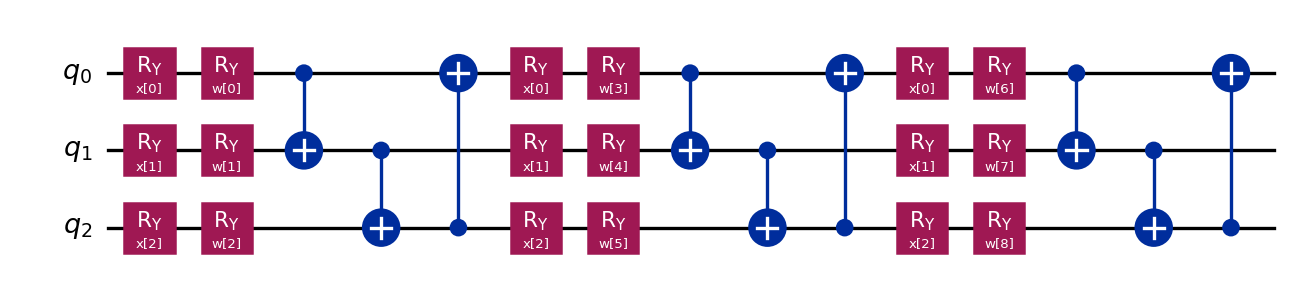

=== GLOBAL CIRCUIT (baseline: RY+CX ring) ===


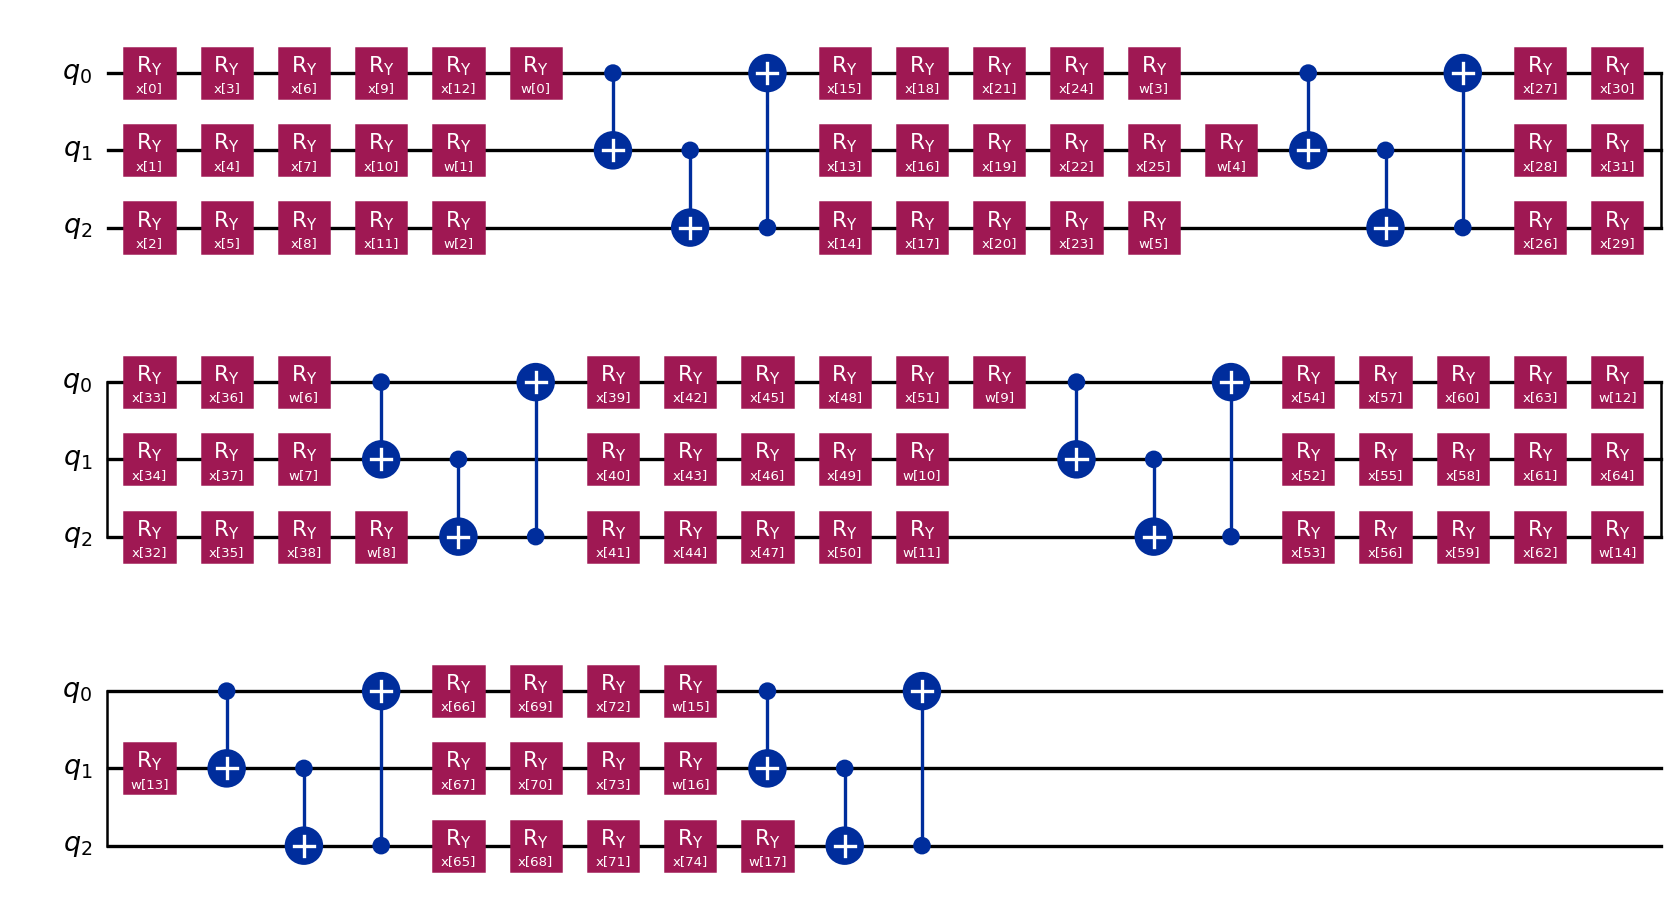

In [6]:
from IPython.display import display
qc_l, x_l, w_l = build_local_circuit(CFG.N_QUBITS, CFG.N_Q_LAYERS)
qc_g, x_g, w_g = build_global_circuit(CFG.N_QUBITS, CFG.N_Q_LAYERS_GLOBAL, CFG.n_inputs())
print('=== LOCAL CIRCUIT ===')
display(qc_l.draw(output='mpl', style='iqp', fold=60))
print('=== GLOBAL CIRCUIT (baseline: RY+CX ring) ===')
display(qc_g.draw(output='mpl', style='iqp', fold=20))


## Build model

In [7]:
model = build_baseline_model(CFG, runner_ctx)
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total:,}')


[Baseline model] Total params: 29,384  (quantum: 27, 0.09%)
Total trainable parameters: 29,384


## Smoke test

In [8]:
model.eval()
x_s, y_s = next(iter(val_loader))
with torch.no_grad():
    out = model(x_s[:2])
print(f'Forward pass OK — output shape: {out.shape}')
print(f'Logits sample: {out[0].detach().numpy().round(4)}')


Forward pass OK — output shape: torch.Size([2, 10])
Logits sample: [-0.0586 -0.126   0.0246  0.0419 -0.0486  0.1028  0.0017 -0.2358 -0.0756
  0.0211]


## Train

The progress bar shows batch loss and running accuracy in real time.

In [9]:
t_start = time.time()

results = train_model(
    model           = model,
    cfg             = CFG,
    runner_ctx      = runner_ctx,
    train_loader    = train_loader,
    val_loader      = val_loader,
    tag             = 'Baseline',
    save_path       = CFG.MODEL_PATH,
    csv_path        = CFG.CSV_PATH,
    n_train_samples = n_train,
    n_val_samples   = n_val,
)

wall_time = time.time() - t_start
print(f'\nTotal wall-clock time: {wall_time:.1f}s  ({wall_time/60:.1f} min)')



  Circuit execution budget — Baseline
  Forward  (train):        22,500  local
                           22,500  global
  Forward  (val):           1,800  local
                            1,800  global
  Backward (train):       405,000  local
                          810,000  global
  ─────────────────────────────────────────────
  Forward total:           48,600
  Backward total:       1,215,000
  Grand total:          1,263,600
  Bwd / Fwd ratio:          25.0×


[Baseline] Epoch  1/3: 100%|███████████████████████████████████████████████████████████████████| 157/157 [11:17<00:00,  4.32s/batch, acc=0.121, loss=2.2950]


  └─ loss=2.2950  train_acc=0.121  val_acc=0.1700  top5=0.6350  val_t=2.3s  total_t=680.2s ✓ saved


[Baseline] Epoch  2/3: 100%|███████████████████████████████████████████████████████████████████| 157/157 [11:16<00:00,  4.31s/batch, acc=0.236, loss=2.0431]


  └─ loss=2.0431  train_acc=0.236  val_acc=0.3200  top5=0.8850  val_t=2.3s  total_t=679.5s ✓ saved


[Baseline] Epoch  3/3: 100%|███████████████████████████████████████████████████████████████████| 157/157 [11:24<00:00,  4.36s/batch, acc=0.382, loss=1.6716]


  └─ loss=1.6716  train_acc=0.382  val_acc=0.4350  top5=0.9200  val_t=2.3s  total_t=687.4s ✓ saved

[Baseline] Training complete. Best val acc: 0.4350  |  Log: results/baseline/training_log.csv

Total wall-clock time: 2047.0s  (34.1 min)


## Training curves

 epoch  train_loss  val_acc  val_top5  epoch_time_s
     1    2.294965    0.170     0.635        680.16
     2    2.043087    0.320     0.885        679.45
     3    1.671619    0.435     0.920        687.35


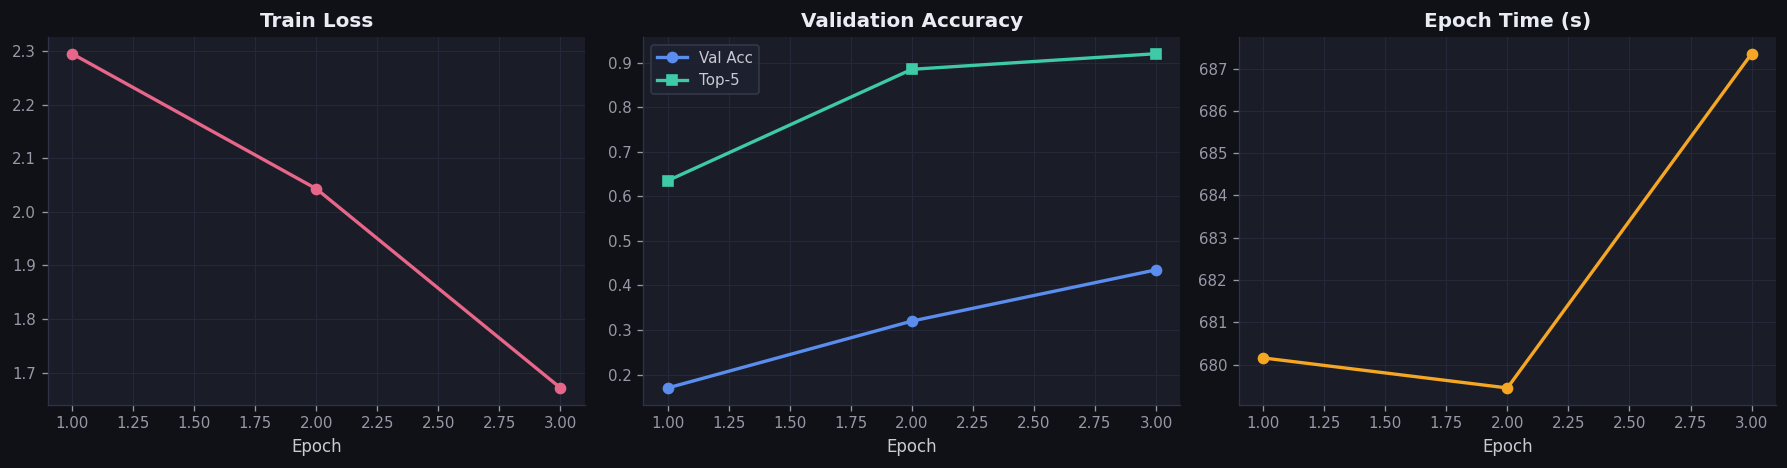

Saved results/baseline/training_curves.png


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(CFG.CSV_PATH)
print(df[['epoch','train_loss','val_acc','val_top5','epoch_time_s']].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(df['epoch'], df['train_loss'], color='#E8668A', marker='o', linewidth=2)
axes[0].set_title('Train Loss', fontweight='bold'); axes[0].set_xlabel('Epoch')

axes[1].plot(df['epoch'], df['val_acc'],  color='#5B8DEF', marker='o', linewidth=2, label='Val Acc')
axes[1].plot(df['epoch'], df['val_top5'], color='#3EC9A7', marker='s', linewidth=2, label='Top-5')
axes[1].set_title('Validation Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(df['epoch'], df['epoch_time_s'], color='#F5A623', marker='o', linewidth=2)
axes[2].set_title('Epoch Time (s)', fontweight='bold'); axes[2].set_xlabel('Epoch')

for ax in axes: ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('results/baseline/training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved results/baseline/training_curves.png')


## Save summary

In [11]:
summary = {
    'variant':            'baseline',
    'best_acc':           results['best_acc'],
    'circuit_counts':     results['circuit_counts'],
    'wall_time_s':        wall_time,
    'epochs':             CFG.EPOCHS,
    'dataset_mode':       CFG.DATASET_MODE,
    'train_samples':      results['n_train'],
    'val_samples':        results['n_val'],
    'n_qubits':           CFG.N_QUBITS,
    'n_gate_params_g':    runner_ctx.n_gate_params_g,
    'n_logical_params_g': runner_ctx.n_logical_params_g,
}
with open('results/baseline/summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('Saved results/baseline/summary.json')
print(f"Best val accuracy  : {results['best_acc']:.4f}")
print(f"Grand total circs  : {results['circuit_counts']['grand_total']:,}")


Saved results/baseline/summary.json
Best val accuracy  : 0.4350
Grand total circs  : 1,263,600
